# GPU V2 — Shared Memory Tiling

Notebook này triển khai phiên bản GPU V2 của thuật toán
local-search Non-Local Means.

Khác biệt chính so với GPU V1:

- GPU V1 đọc trực tiếp dữ liệu patch từ global memory.
- GPU V2 cho các thread trong cùng block hợp tác tải một tile
  cùng vùng halo vào shared memory.
- Các pixel chồng lặp giữa các patch được tái sử dụng trong block.
- Mỗi CUDA thread vẫn phụ trách một output pixel.

Notebook thực hiện:

1. Kiểm tra môi trường CUDA.
2. Chuẩn bị ảnh đầu vào 512 × 512.
3. Chạy GPU V1 và GPU V2.
4. Kiểm tra correctness.
5. Đo kernel-only runtime.
6. Đo end-to-end runtime.
7. So sánh GPU V1 và GPU V2.

In [1]:
from pathlib import Path
import sys


NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("Current directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)

Current directory: e:\Lap trinh song song ud\gpu_dense_vector_retrieval\notebooks
Project root: e:\Lap trinh song song ud\gpu_dense_vector_retrieval


## 1. Import thư viện

Notebook sử dụng:

- NumPy để quản lý ảnh trên CPU;
- CuPy để quản lý dữ liệu và kernel CUDA;
- Matplotlib để trực quan hóa ảnh;
- các module chung của dự án cho preprocessing, metrics và benchmark;
- GPU V1 để làm baseline;
- GPU V2 để đánh giá tác động của shared memory.

In [2]:
import time

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
from src.nlm.config import NLMConfig

from src.nlm.image_utils import (
    add_gaussian_noise,
    create_camera_test_image,
)

from src.nlm.metrics import (
    compare_outputs,
    evaluate_denoising,
)

from src.nlm.benchmark import (
    benchmark_cuda_kernel,
    benchmark_gpu_end_to_end,
)

from src.nlm.gpu_v1 import (
    nlm_gpu_v1,
    create_gpu_v1_kernel_launcher,
)

from src.nlm.gpu_v2 import (
    nlm_gpu_v2,
    prepare_gpu_v2_kernel_launch,
)

In [4]:
print("CuPy version:", cp.__version__)

device_count = cp.cuda.runtime.getDeviceCount()

print("CUDA device count:", device_count)

if device_count <= 0:
    raise RuntimeError(
        "Không tìm thấy CUDA-capable GPU."
    )

device = cp.cuda.Device()

device.use()

device_properties = (
    cp.cuda.runtime.getDeviceProperties(
        device.id
    )
)

device_name = device_properties["name"]

if isinstance(device_name, bytes):
    device_name = device_name.decode()

print("Current GPU:", device_name)
print("Device ID:", device.id)

CuPy version: 14.1.1
CUDA device count: 1
Current GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Device ID: 0


## 2. Cấu hình thí nghiệm

Thí nghiệm sử dụng ảnh grayscale có kích thước 512 × 512.

Các tham số NLM:

- Gaussian noise sigma: 0.08
- Patch size: 3 × 3
- Search window: 7 × 7
- Filtering parameter h: 0.12
- Random seed: 42
- CUDA block size: 16 × 16

Với cấu hình trên:

- patch radius = 1;
- search radius = 3;
- halo radius = 4;
- output tile = 16 × 16;
- shared-memory tile = 24 × 24.

In [5]:
config = NLMConfig(
    image_size=512,
    noise_sigma=0.08,
    patch_size=3,
    search_window_size=7,
    h=0.12,
    random_seed=42,
    block_size_x=16,
    block_size_y=16,
)

config.validate()

print("Cấu hình NLM:")
print(config)

print(
    "\nImage size:",
    f"{config.image_size} × {config.image_size}",
)

print(
    "Patch radius:",
    config.patch_radius,
)

print(
    "Search radius:",
    config.search_radius,
)

print(
    "Padding radius / halo radius:",
    config.padding_radius,
)

print(
    "CUDA block size:",
    config.block_size,
)

print(
    "Threads per block:",
    config.block_size_x
    * config.block_size_y,
)

Cấu hình NLM:
NLMConfig(image_size=512, noise_sigma=0.08, patch_size=3, search_window_size=7, h=0.12, random_seed=42, block_size_x=16, block_size_y=16)

Image size: 512 × 512
Patch radius: 1
Search radius: 3
Padding radius / halo radius: 4
CUDA block size: (16, 16)
Threads per block: 256


In [6]:
image_width = config.image_size
image_height = config.image_size

block_x = config.block_size_x
block_y = config.block_size_y

grid_x = (
    image_width + block_x - 1
) // block_x

grid_y = (
    image_height + block_y - 1
) // block_y

halo_radius = config.padding_radius

shared_tile_width = (
    block_x + 2 * halo_radius
)

shared_tile_height = (
    block_y + 2 * halo_radius
)

shared_memory_bytes = (
    shared_tile_width
    * shared_tile_height
    * np.dtype(np.float32).itemsize
)

print("Grid size:", (grid_x, grid_y))
print(
    "Number of blocks:",
    grid_x * grid_y,
)

print(
    "Output tile:",
    (block_x, block_y),
)

print(
    "Shared tile:",
    (
        shared_tile_width,
        shared_tile_height,
    ),
)

print(
    "Shared memory per block:",
    shared_memory_bytes,
    "bytes",
)

Grid size: (32, 32)
Number of blocks: 1024
Output tile: (16, 16)
Shared tile: (24, 24)
Shared memory per block: 2304 bytes


## 3. Chuẩn bị ảnh đầu vào

Notebook tạo một clean grayscale image 512 × 512,
sau đó thêm Gaussian noise với sigma 0.08.

Random seed được cố định bằng 42 để:

- tạo cùng một noise pattern giữa các lần chạy;
- bảo đảm GPU V1 và GPU V2 nhận cùng input;
- giúp kết quả correctness và benchmark có thể tái lập.

In [7]:
clean_image = create_camera_test_image(
    image_size=config.image_size,
)

noisy_image = add_gaussian_noise(
    image=clean_image,
    sigma=config.noise_sigma,
    seed=config.random_seed,
)

clean_image = np.ascontiguousarray(
    clean_image,
    dtype=np.float32,
)

noisy_image = np.ascontiguousarray(
    noisy_image,
    dtype=np.float32,
)

print("Clean image:")
print("  shape:", clean_image.shape)
print("  dtype:", clean_image.dtype)
print(
    "  range:",
    float(clean_image.min()),
    "→",
    float(clean_image.max()),
)

print("\nNoisy image:")
print("  shape:", noisy_image.shape)
print("  dtype:", noisy_image.dtype)
print(
    "  range:",
    float(noisy_image.min()),
    "→",
    float(noisy_image.max()),
)

Clean image:
  shape: (512, 512)
  dtype: float32
  range: 0.0 → 1.0

Noisy image:
  shape: (512, 512)
  dtype: float32
  range: 0.0 → 1.0


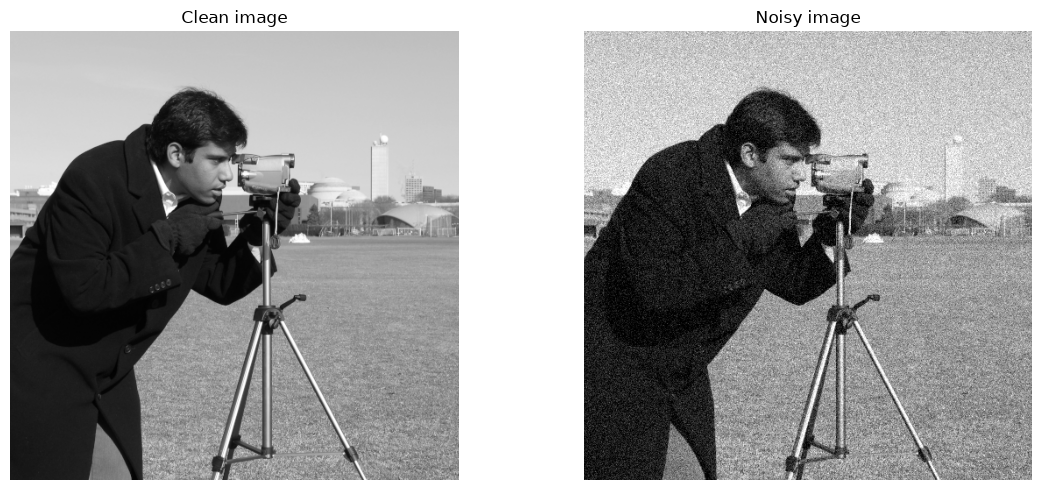

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(
    clean_image,
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)
plt.title("Clean image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    noisy_image,
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)
plt.title("Noisy image")
plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Chạy GPU V1

GPU V1 được chạy trước để làm baseline cho GPU V2.

Trong GPU V1:

- mỗi CUDA thread xử lý một output pixel;
- các patch được đọc trực tiếp từ global memory;
- các thread lân cận có thể đọc lại nhiều pixel giống nhau.

In [9]:
gpu_v1_start = time.perf_counter()

denoised_gpu_v1 = nlm_gpu_v1(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
    block_size=config.block_size,
)

cp.cuda.get_current_stream().synchronize()

gpu_v1_single_runtime = (
    time.perf_counter()
    - gpu_v1_start
)

print(
    "GPU V1 single-run runtime:",
    gpu_v1_single_runtime,
    "seconds",
)

print(
    "GPU V1 output shape:",
    denoised_gpu_v1.shape,
)

print(
    "GPU V1 output dtype:",
    denoised_gpu_v1.dtype,
)

print(
    "GPU V1 range:",
    float(denoised_gpu_v1.min()),
    "→",
    float(denoised_gpu_v1.max()),
)

GPU V1 single-run runtime: 0.46180509999976493 seconds
GPU V1 output shape: (512, 512)
GPU V1 output dtype: float32
GPU V1 range: 0.019217967987060547 → 0.9877172708511353


## 5. Chạy GPU V2

GPU V2 sử dụng shared-memory tiling.

Đối với mỗi block:

1. Các thread xác định output tile 16 × 16.
2. Các thread hợp tác tải shared tile 24 × 24.
3. Shared tile bao gồm output region và halo radius 4.
4. `__syncthreads()` bảo đảm quá trình load hoàn tất.
5. Mỗi thread tính một output pixel bằng dữ liệu trong shared memory.

Chạy GPU V2 một lần

In [10]:
gpu_v2_start = time.perf_counter()

denoised_gpu_v2 = nlm_gpu_v2(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
    block_size=config.block_size,
)

cp.cuda.get_current_stream().synchronize()

gpu_v2_single_runtime = (
    time.perf_counter()
    - gpu_v2_start
)

print(
    "GPU V2 single-run runtime:",
    gpu_v2_single_runtime,
    "seconds",
)

print(
    "GPU V2 output shape:",
    denoised_gpu_v2.shape,
)

print(
    "GPU V2 output dtype:",
    denoised_gpu_v2.dtype,
)

print(
    "GPU V2 range:",
    float(denoised_gpu_v2.min()),
    "→",
    float(denoised_gpu_v2.max()),
)

GPU V2 single-run runtime: 0.028004899999359623 seconds
GPU V2 output shape: (512, 512)
GPU V2 output dtype: float32
GPU V2 range: 0.019217967987060547 → 0.9877172708511353


## 6. Kiểm tra correctness

GPU V2 phải tạo kết quả gần với GPU V1 trong giới hạn sai số floating point.

Hai output được so sánh trên toàn bộ pixel bằng:

- maximum absolute error;
- mean absolute error;
- RMSE;
- `numpy.allclose`.

Việc xác minh correctness cần được thực hiện trước khi đánh giá performance. 

In [11]:
gpu_v2_vs_v1 = compare_outputs(
    reference=denoised_gpu_v1,
    candidate=denoised_gpu_v2,
    atol=1e-5,
    rtol=1e-5,
)

gpu_v2_vs_v1

{'max_absolute_error': 0.0,
 'mean_absolute_error': 0.0,
 'rmse': 0.0,
 'allclose': True}

In [12]:
print("GPU V2 vs GPU V1 correctness:")

for key, value in gpu_v2_vs_v1.items():
    print(f"{key}: {value}")

GPU V2 vs GPU V1 correctness:
max_absolute_error: 0.0
mean_absolute_error: 0.0
rmse: 0.0
allclose: True


Tạo error map

In [13]:
absolute_error_map = np.abs(
    denoised_gpu_v1.astype(np.float64)
    - denoised_gpu_v2.astype(np.float64)
)

print(
    "Maximum absolute error:",
    float(absolute_error_map.max()),
)

print(
    "Mean absolute error:",
    float(absolute_error_map.mean()),
)

Maximum absolute error: 0.0
Mean absolute error: 0.0


In [14]:
absolute_error_map = np.abs(
    denoised_gpu_v1.astype(np.float64)
    - denoised_gpu_v2.astype(np.float64)
)

print(
    "Maximum absolute error:",
    float(absolute_error_map.max()),
)

print(
    "Mean absolute error:",
    float(absolute_error_map.mean()),
)

Maximum absolute error: 0.0
Mean absolute error: 0.0


Hiển thị kết quả định tính

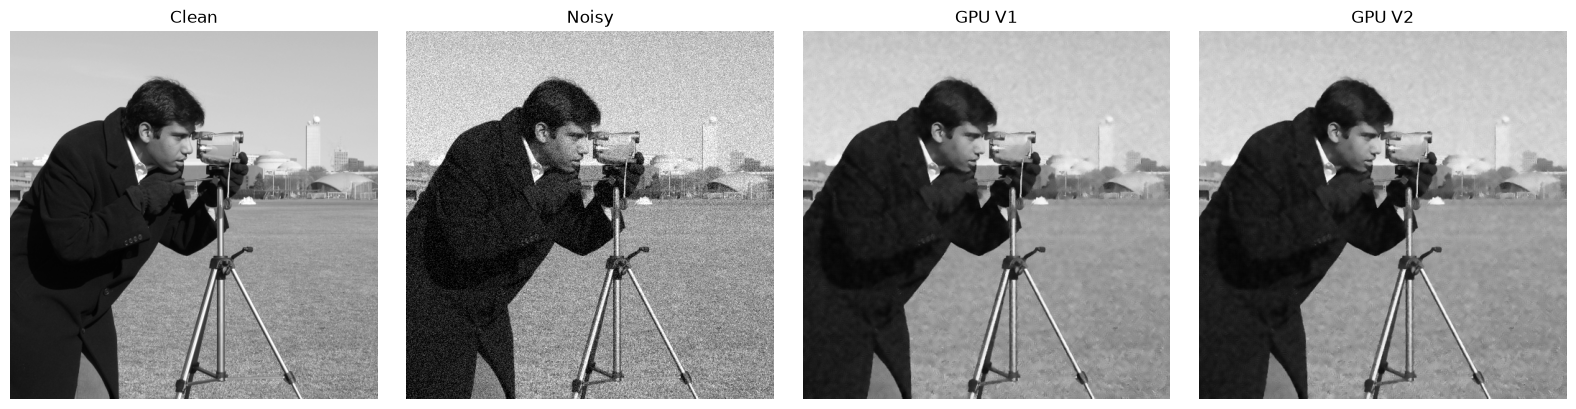

In [15]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(
    clean_image,
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)
plt.title("Clean")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(
    noisy_image,
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(
    denoised_gpu_v1,
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)
plt.title("GPU V1")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(
    denoised_gpu_v2,
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)
plt.title("GPU V2")
plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Đánh giá chất lượng denoising

Các output GPU được so với clean image bằng:

- PSNR;
- SSIM;
- PSNR improvement so với noisy image.

GPU V1 và GPU V2 thực hiện cùng thuật toán,
nên các metric chất lượng được kỳ vọng gần như giống nhau.

In [16]:
gpu_v1_quality = evaluate_denoising(
    clean=clean_image,
    noisy=noisy_image,
    denoised=denoised_gpu_v1,
)

gpu_v2_quality = evaluate_denoising(
    clean=clean_image,
    noisy=noisy_image,
    denoised=denoised_gpu_v2,
)

quality_table = pd.DataFrame(
    [
        {
            "Implementation": "GPU V1",
            **gpu_v1_quality,
        },
        {
            "Implementation": "GPU V2",
            **gpu_v2_quality,
        },
    ]
)

quality_table

,Implementation,noisy_psnr,denoised_psnr,denoised_ssim,psnr_improvement
0,GPU V1,22.232281,29.668976,0.76318,7.436695
1,GPU V2,22.232281,29.668976,0.76318,7.436695


## 8. Kernel-only benchmark

Kernel-only benchmark chỉ đo thời gian CUDA kernel.

Dữ liệu input GPU, output GPU và memory allocation
được chuẩn bị trước khi bắt đầu đo.

Do đó thời gian này không bao gồm:

- CPU reflect padding;
- Host-to-Device transfer;
- GPU allocation;
- Device-to-Host transfer.

Chuẩn bị kernel launcher GPU V2

In [17]:
gpu_v2_prepared = (
    prepare_gpu_v2_kernel_launch(
        image=noisy_image,
        patch_size=config.patch_size,
        search_window_size=(
            config.search_window_size
        ),
        h=config.h,
        block_size=config.block_size,
    )
)

print(
    "Grid size:",
    gpu_v2_prepared["grid_size"],
)

print(
    "Block size:",
    gpu_v2_prepared["block_size"],
)

print(
    "Shared memory per block:",
    gpu_v2_prepared[
        "shared_memory_bytes"
    ],
    "bytes",
)

Grid size: (32, 32)
Block size: (16, 16)
Shared memory per block: 2304 bytes


In [18]:
gpu_v2_kernel_benchmark = (
    benchmark_cuda_kernel(
        kernel_launcher=(
            gpu_v2_prepared[
                "kernel_launcher"
            ]
        ),
        warmup_runs=3,
        measured_runs=50,
    )
)

gpu_v2_kernel_benchmark

{'times_ms': array([0.64409602, 0.63078398, 0.62976003, 0.63078398, 0.62873602,
        0.63180798, 0.63078398, 0.64102399, 0.64819199, 0.62873602,
        0.70963198, 0.64716798, 0.625664  , 0.63180798, 0.64307201,
        0.63999999, 0.64102399, 0.66867203, 0.626688  , 0.642048  ,
        0.66969597, 0.672768  , 0.6656    , 0.67788798, 0.6656    ,
        0.657408  , 0.64512002, 0.64716798, 0.66457599, 0.68198401,
        0.66969597, 0.657408  , 0.66969597, 0.66252798, 0.67788798,
        0.65945601, 0.67174399, 0.65126401, 0.65024   , 0.65638399,
        0.63999999, 0.66867203, 0.66764802, 0.65535998, 0.66764802,
        0.66048002, 0.65126401, 0.65331203, 0.64716798, 0.83148801]),
 'median_ms': 0.652288019657135,
 'mean_ms': 0.6567526376247406,
 'std_ms': 0.030428319146541837,
 'min_ms': 0.6256639957427979,
 'max_ms': 0.8314880132675171}

## 9. End-to-end benchmark

End-to-end benchmark đo toàn bộ lời gọi `nlm_gpu_v2()`.

Phạm vi bao gồm:

- CPU reflect padding;
- GPU memory allocation;
- Host-to-Device transfer;
- kernel execution;
- Device-to-Host transfer;
- chuyển output về NumPy.

Hai warm-up runs được thực hiện trước khi đo.
Kết quả đại diện cho steady-state end-to-end runtime.

In [19]:
gpu_v2_end_to_end_benchmark = (
    benchmark_gpu_end_to_end(
        function=lambda: nlm_gpu_v2(
            image=noisy_image,
            patch_size=config.patch_size,
            search_window_size=(
                config.search_window_size
            ),
            h=config.h,
            block_size=config.block_size,
        ),
        warmup_runs=2,
        measured_runs=20,
    )
)

gpu_v2_end_to_end_benchmark

{'times_seconds': array([0.0024255, 0.0021275, 0.002121 , 0.0018911, 0.0018349, 0.0019854,
        0.0020387, 0.0021821, 0.0020415, 0.002217 , 0.0019822, 0.002033 ,
        0.0021294, 0.0019509, 0.002024 , 0.0020146, 0.0019908, 0.0018622,
        0.0019008, 0.0018916]),
 'median_seconds': 0.002019300000029034,
 'mean_seconds': 0.0020322099999248167,
 'std_seconds': 0.00013711535244269964,
 'min_seconds': 0.001834900000176276,
 'max_seconds': 0.0024254999989352655}

Benchmark GPU V1 end-to-end để so sánh

In [20]:
gpu_v1_end_to_end_benchmark = (
    benchmark_gpu_end_to_end(
        function=lambda: nlm_gpu_v1(
            image=noisy_image,
            patch_size=config.patch_size,
            search_window_size=(
                config.search_window_size
            ),
            h=config.h,
            block_size=config.block_size,
        ),
        warmup_runs=2,
        measured_runs=20,
    )
)

gpu_v1_end_to_end_benchmark

{'times_seconds': array([0.0028441, 0.0027896, 0.0020472, 0.0018191, 0.0022019, 0.0023621,
        0.0020837, 0.0019085, 0.0021042, 0.0023838, 0.0021917, 0.0021915,
        0.0022501, 0.0023671, 0.0021057, 0.0021616, 0.0024073, 0.0021234,
        0.0019844, 0.0020903]),
 'median_seconds': 0.002176549999603594,
 'mean_seconds': 0.002220864999890182,
 'std_seconds': 0.00024882278912424587,
 'min_seconds': 0.0018190999999205815,
 'max_seconds': 0.0028441000013117446}

In [21]:
gpu_v1_median_seconds = (
    gpu_v1_end_to_end_benchmark[
        "median_seconds"
    ]
)

gpu_v2_median_seconds = (
    gpu_v2_end_to_end_benchmark[
        "median_seconds"
    ]
)

v2_speedup_over_v1 = (
    gpu_v1_median_seconds
    / gpu_v2_median_seconds
)

comparison_table = pd.DataFrame(
    [
        {
            "Implementation": "GPU V1",
            "Scope": (
                "Steady-state end-to-end"
            ),
            "Median runtime (s)": (
                gpu_v1_median_seconds
            ),
            "Relative speedup": 1.0,
        },
        {
            "Implementation": "GPU V2",
            "Scope": (
                "Steady-state end-to-end"
            ),
            "Median runtime (s)": (
                gpu_v2_median_seconds
            ),
            "Relative speedup": (
                v2_speedup_over_v1
            ),
        },
    ]
)

comparison_table

,Implementation,Scope,Median runtime (s),Relative speedup
0,GPU V1,Steady-state end-to-end,0.002177,1.000000
1,GPU V2,Steady-state end-to-end,0.002019,1.077874


In [22]:
print(
    "GPU V1 median end-to-end:",
    f"{gpu_v1_median_seconds:.6f} s",
)

print(
    "GPU V2 median end-to-end:",
    f"{gpu_v2_median_seconds:.6f} s",
)

print(
    "GPU V2 speedup over GPU V1:",
    f"{v2_speedup_over_v1:.2f}×",
)

GPU V1 median end-to-end: 0.002177 s
GPU V2 median end-to-end: 0.002019 s
GPU V2 speedup over GPU V1: 1.08×


So sánh kernel và end-to-end GPU V2

## So sánh kernel-only giữa GPU V1 và GPU V2

Phép đo end-to-end bao gồm cả padding, cấp phát bộ nhớ,
Host-to-Device transfer, kernel execution và Device-to-Host transfer.

Để đánh giá trực tiếp tác động của shared-memory tiling,
cần so sánh kernel-only giữa:

- GPU V1: đọc dữ liệu trực tiếp từ global memory;
- GPU V2: tải tile và halo vào shared memory.

Hai kernel được đo trên cùng input, cùng cấu hình CUDA block
và trong cùng một phiên notebook.

In [23]:
gpu_v2_kernel_seconds = (
    gpu_v2_kernel_benchmark[
        "median_ms"
    ]
    / 1000.0
)

gpu_v2_end_to_end_seconds = (
    gpu_v2_end_to_end_benchmark[
        "median_seconds"
    ]
)

kernel_fraction = (
    gpu_v2_kernel_seconds
    / gpu_v2_end_to_end_seconds
)

print(
    "GPU V2 kernel-only:",
    f"{gpu_v2_kernel_seconds:.6f} s",
)

print(
    "GPU V2 end-to-end:",
    f"{gpu_v2_end_to_end_seconds:.6f} s",
)

print(
    "Kernel fraction:",
    f"{kernel_fraction * 100:.2f}%",
)

print(
    "Non-kernel fraction:",
    f"{(1.0 - kernel_fraction) * 100:.2f}%",
)

GPU V2 kernel-only: 0.000652 s
GPU V2 end-to-end: 0.002019 s
Kernel fraction: 32.30%
Non-kernel fraction: 67.70%


In [24]:
gpu_v1_kernel_launcher, gpu_v1_output_gpu = (
    create_gpu_v1_kernel_launcher(
        image=noisy_image,
        patch_size=config.patch_size,
        search_window_size=(
            config.search_window_size
        ),
        h=config.h,
        block_size=config.block_size,
    )
)

print("GPU V1 kernel launcher prepared.")
print(
    "GPU V1 output buffer shape:",
    gpu_v1_output_gpu.shape,
)
print(
    "GPU V1 output dtype:",
    gpu_v1_output_gpu.dtype,
)

GPU V1 kernel launcher prepared.
GPU V1 output buffer shape: (512, 512)
GPU V1 output dtype: float32


In [25]:
for _ in range(20):
    gpu_v1_kernel_launcher()
    gpu_v2_prepared[
        "kernel_launcher"
    ]()

cp.cuda.get_current_stream().synchronize()

print("GPU V1 and GPU V2 pre-warm completed.")

GPU V1 and GPU V2 pre-warm completed.


In [26]:
gpu_v1_kernel_benchmark = (
    benchmark_cuda_kernel(
        kernel_launcher=(
            gpu_v1_kernel_launcher
        ),
        warmup_runs=10,
        measured_runs=50,
    )
)

gpu_v1_kernel_benchmark

{'times_ms': array([0.86323202, 0.923648  , 0.94208002, 0.91340798, 0.915456  ,
        0.92979199, 0.884736  , 0.884736  , 0.88780802, 0.891904  ,
        0.93593597, 0.88678402, 0.87449598, 0.86527997, 0.88166398,
        0.869376  , 0.86630398, 0.86732799, 0.91340798, 0.955392  ,
        0.97587198, 0.98303998, 0.95641601, 0.97382402, 0.95846403,
        0.9472    , 0.98201603, 0.97792   , 0.95231998, 0.96153599,
        0.94617599, 0.94515198, 0.94208002, 0.94310403, 0.94310403,
        0.96665603, 0.99839997, 0.96153599, 0.96972799, 0.95334399,
        0.95948797, 0.96153599, 0.96358401, 0.986112  , 0.97689599,
        1.00454402, 0.96256   , 0.96153599, 0.96051198, 0.96051198]),
 'median_ms': 0.9497599899768829,
 'mean_ms': 0.9377587175369263,
 'std_ms': 0.039143217875274354,
 'min_ms': 0.8632320165634155,
 'max_ms': 1.0045440196990967}

In [27]:
gpu_v2_kernel_benchmark = (
    benchmark_cuda_kernel(
        kernel_launcher=(
            gpu_v2_prepared[
                "kernel_launcher"
            ]
        ),
        warmup_runs=10,
        measured_runs=50,
    )
)

gpu_v2_kernel_benchmark

{'times_ms': array([0.91443199, 0.87142402, 0.84377599, 0.86015999, 0.83455998,
        0.83148801, 0.82841599, 0.73113602, 0.73830402, 0.73318398,
        0.76902401, 0.75673598, 0.790528  , 0.78950399, 0.78336   ,
        0.78745598, 0.79667199, 0.78028798, 0.78540802, 0.78540802,
        0.78336   , 0.78438401, 0.79155201, 0.805888  , 0.782336  ,
        0.78028798, 0.78438401, 0.78438401, 0.78540802, 0.78540802,
        0.805888  , 0.87551999, 0.93593597, 0.90419197, 0.89702398,
        0.908288  , 0.89087999, 0.88678402, 0.891904  , 0.87859201,
        0.87244803, 0.89087999, 0.90623999, 0.89702398, 0.8448    ,
        0.82329601, 0.85811198, 0.87142402, 0.84172797, 0.84070402]),
 'median_ms': 0.8258560001850128,
 'mean_ms': 0.8280063986778259,
 'std_ms': 0.05335029704472538,
 'min_ms': 0.7311360239982605,
 'max_ms': 0.9359359741210938}

In [28]:
gpu_v1_kernel_ms = (
    gpu_v1_kernel_benchmark[
        "median_ms"
    ]
)

gpu_v2_kernel_ms = (
    gpu_v2_kernel_benchmark[
        "median_ms"
    ]
)

gpu_v2_kernel_speedup = (
    gpu_v1_kernel_ms
    / gpu_v2_kernel_ms
)

gpu_v2_kernel_change_percent = (
    (
        gpu_v2_kernel_ms
        - gpu_v1_kernel_ms
    )
    / gpu_v1_kernel_ms
    * 100.0
)

kernel_comparison_table = pd.DataFrame(
    [
        {
            "Implementation": "GPU V1",
            "Memory strategy": (
                "Direct global-memory access"
            ),
            "Median kernel runtime (ms)": (
                gpu_v1_kernel_ms
            ),
            "Speedup vs GPU V1": 1.0,
        },
        {
            "Implementation": "GPU V2",
            "Memory strategy": (
                "Shared-memory tile + halo"
            ),
            "Median kernel runtime (ms)": (
                gpu_v2_kernel_ms
            ),
            "Speedup vs GPU V1": (
                gpu_v2_kernel_speedup
            ),
        },
    ]
)

kernel_comparison_table

,Implementation,Memory strategy,Median kernel runtime (ms),Speedup vs GPU V1
0,GPU V1,Direct global-memory access,0.949760,1.000000
1,GPU V2,Shared-memory tile + halo,0.825856,1.150031


So sánh end-to-end

In [30]:
gpu_v1_end_to_end_ms = (
    gpu_v1_end_to_end_benchmark[
        "median_seconds"
    ]
    * 1000.0
)

gpu_v2_end_to_end_ms = (
    gpu_v2_end_to_end_benchmark[
        "median_seconds"
    ]
    * 1000.0
)

gpu_v2_end_to_end_speedup = (
    gpu_v1_end_to_end_ms
    / gpu_v2_end_to_end_ms
)

full_comparison_table = pd.DataFrame(
    [
        {
            "Scope": "Kernel only",
            "GPU V1 runtime (ms)": (
                gpu_v1_kernel_ms
            ),
            "GPU V2 runtime (ms)": (
                gpu_v2_kernel_ms
            ),
            "GPU V2 speedup": (
                gpu_v2_kernel_speedup
            ),
        },
        {
            "Scope": (
                "Steady-state end-to-end"
            ),
            "GPU V1 runtime (ms)": (
                gpu_v1_end_to_end_ms
            ),
            "GPU V2 runtime (ms)": (
                gpu_v2_end_to_end_ms
            ),
            "GPU V2 speedup": (
                gpu_v2_end_to_end_speedup
            ),
        },
    ]
)

full_comparison_table

,Scope,GPU V1 runtime (ms),GPU V2 runtime (ms),GPU V2 speedup
0,Kernel only,0.94976,0.825856,1.150031
1,Steady-state end-to-end,2.17655,2.019300,1.077874


In [31]:
print(
    "GPU V1 kernel-only:",
    f"{gpu_v1_kernel_ms:.6f} ms",
)

print(
    "GPU V2 kernel-only:",
    f"{gpu_v2_kernel_ms:.6f} ms",
)

print(
    "GPU V2 kernel speedup:",
    f"{gpu_v2_kernel_speedup:.3f}×",
)

print(
    "GPU V2 kernel runtime change:",
    f"{gpu_v2_kernel_change_percent:+.2f}%",
)

print()

print(
    "GPU V1 end-to-end:",
    f"{gpu_v1_end_to_end_ms:.6f} ms",
)

print(
    "GPU V2 end-to-end:",
    f"{gpu_v2_end_to_end_ms:.6f} ms",
)

print(
    "GPU V2 end-to-end speedup:",
    f"{gpu_v2_end_to_end_speedup:.3f}×",
)

GPU V1 kernel-only: 0.949760 ms
GPU V2 kernel-only: 0.825856 ms
GPU V2 kernel speedup: 1.150×
GPU V2 kernel runtime change: -13.05%

GPU V1 end-to-end: 2.176550 ms
GPU V2 end-to-end: 2.019300 ms
GPU V2 end-to-end speedup: 1.078×


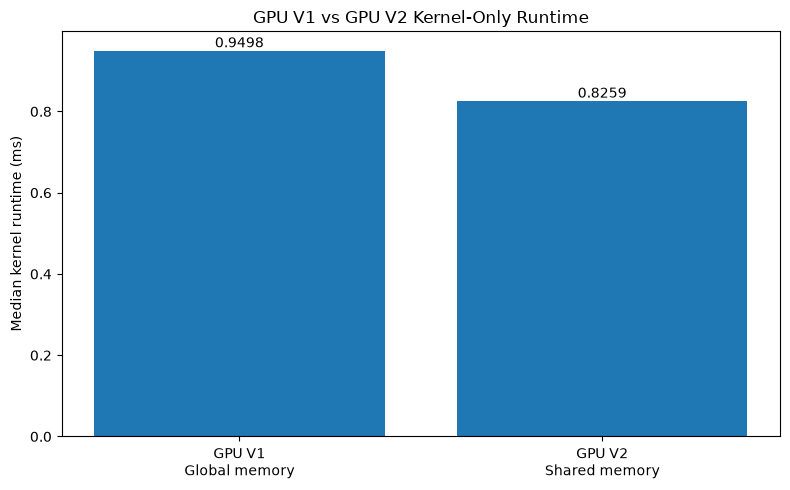

In [32]:
kernel_labels = [
    "GPU V1\nGlobal memory",
    "GPU V2\nShared memory",
]

kernel_values = [
    gpu_v1_kernel_ms,
    gpu_v2_kernel_ms,
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    kernel_labels,
    kernel_values,
)

plt.ylabel("Median kernel runtime (ms)")
plt.title(
    "GPU V1 vs GPU V2 Kernel-Only Runtime"
)

for bar, value in zip(
    bars,
    kernel_values,
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

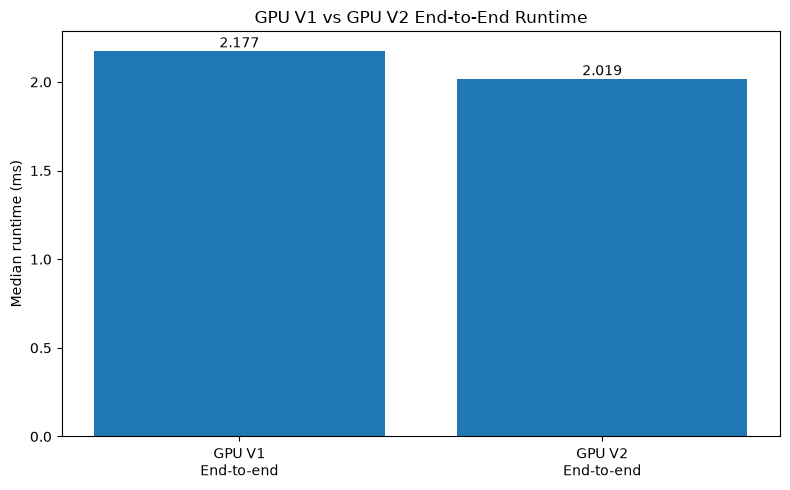

In [34]:
runtime_labels = [
    "GPU V1\nEnd-to-end",
    "GPU V2\nEnd-to-end",
]

runtime_values_ms = [
    gpu_v1_median_seconds * 1000.0,
    gpu_v2_median_seconds * 1000.0,
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    runtime_labels,
    runtime_values_ms,
)

plt.ylabel("Median runtime (ms)")
plt.title(
    "GPU V1 vs GPU V2 End-to-End Runtime"
)

for bar, value in zip(
    bars,
    runtime_values_ms,
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

## 10. Kết luận

GPU V2 giữ nguyên mô hình một thread xử lý một output pixel,
nhưng thay đổi cách truy cập dữ liệu.

Trong GPU V1:

- reference patch và candidate patches được đọc trực tiếp
  từ global memory;
- các thread lân cận đọc lặp nhiều pixel chồng lặp.

Trong GPU V2:

- các thread trong một block hợp tác tải tile và halo;
- dữ liệu được lưu trong shared memory;
- các thread tái sử dụng dữ liệu trong quá trình quét search window;
- số lần đọc lặp từ global memory được giảm.

Correctness được xác minh bằng so sánh toàn bộ pixel giữa
GPU V1 và GPU V2.

Performance được báo cáo theo hai scope:

- kernel-only runtime;
- steady-state end-to-end runtime.

End-to-end runtime được sử dụng làm kết quả chính khi đánh giá
hiệu quả thực tế của GPU V2.